# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **Brain Tumor MRI Dataset**, un dataset de radiografías de craneo en formato 2D, con etiquetas binarias (glicoma vs. notumor).

Al final se verá:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
import sys
import subprocess
import random

packages = [
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "kagglehub"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (Brain Tumor MRI Dataset)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de cráneo) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [3]:
!pip install -q kaggle
from google.colab import files
files.upload()  # subir el repositorio de las imágenes kaggle.json
!mkdir -p ~/.kaggle && echo KGAT_6ec2b800c1e1d1d83847d268d13a1bb7 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset/data
!unzip -q archivo.zip -d brain-tumor-mri-dataset

Saving archive.zip to archive.zip
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/data
License(s): Attribution 4.0 International (CC BY 4.0)
invalid literal for int() with base 10: 'data'
unzip:  cannot find or open archivo.zip, archivo.zip.zip or archivo.zip.ZIP.


In [7]:
import kagglehub
# Poner el identificador del dataset de tumores cerebrales.
dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset descargado en:", dataset_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset descargado en: /kaggle/input/brain-tumor-mri-dataset


In [8]:
import os

# Ver la estructura de carpetas para ubicar train/test
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        continue

brain-tumor-mri-dataset/
  Training/
    pituitary/
    notumor/
    meningioma/
    glioma/
  Testing/
    pituitary/
    notumor/
    meningioma/
    glioma/


In [9]:
# Ajustar las rutas según lo que haya mostrado el listado de carpetas: <dataset_path>/train y <dataset_path>/test
# En este data set de tumores cerebrales, las carpetas se llamaran "Training" y "Testing".
train_dir_candidates = [os.path.join(dataset_path, "train"), os.path.join(dataset_path, "Training"), os.path.join(dataset_path, "data", "train")]
test_dir_candidates  = [os.path.join(dataset_path, "test"), os.path.join(dataset_path, "Testing"), os.path.join(dataset_path, "data", "test")]

train_dir = next(p for p in train_dir_candidates if os.path.isdir(p))
test_dir  = next(p for p in test_dir_candidates  if os.path.isdir(p))

print("train_dir:", train_dir)
print("test_dir: ", test_dir)
print("Clases encontradas:", os.listdir(train_dir))

train_dir: /kaggle/input/brain-tumor-mri-dataset/Training
test_dir:  /kaggle/input/brain-tumor-mri-dataset/Testing
Clases encontradas: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [18]:
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

IMG_SIZE = 128  # Mejoramiento de la resolución para captar mejores detalles

# Determinar solo 2 categorias: "glioma" y "no_tumor"
clases_permitidas = ['glioma', 'notumor']

def filter_2_classes(dataset, allowed_classes):
    # Encontrar los índices originales de las clases permitidas
    allowed_indices = {dataset.class_to_idx[cls]: i for i, cls in enumerate(allowed_classes) if cls in dataset.class_to_idx}

    # Filtrar las muestras
    new_samples = [(path, allowed_indices[label]) for path, label in dataset.samples if label in allowed_indices]

    dataset.samples = new_samples
    dataset.targets = [s[1] for s in new_samples]
    dataset.classes = allowed_classes
    dataset.class_to_idx = {cls: i for i, cls in enumerate(allowed_classes)}
    return dataset

full_train_dataset = filter_2_classes(full_train_dataset, clases_permitidas)
test_dataset = filter_2_classes(test_dataset, clases_permitidas)

#Dividir en Train y Val (80/20)
val_size = int(len(full_train_dataset) * 0.2)
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Para validación, quitamos el Data Augmentation
val_dataset.dataset.transform = test_transforms

# 5. DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Clases finales: {full_train_dataset.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Clases finales: ['glioma', 'notumor']
Train: 2240 | Val: 560 | Test: 800


### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


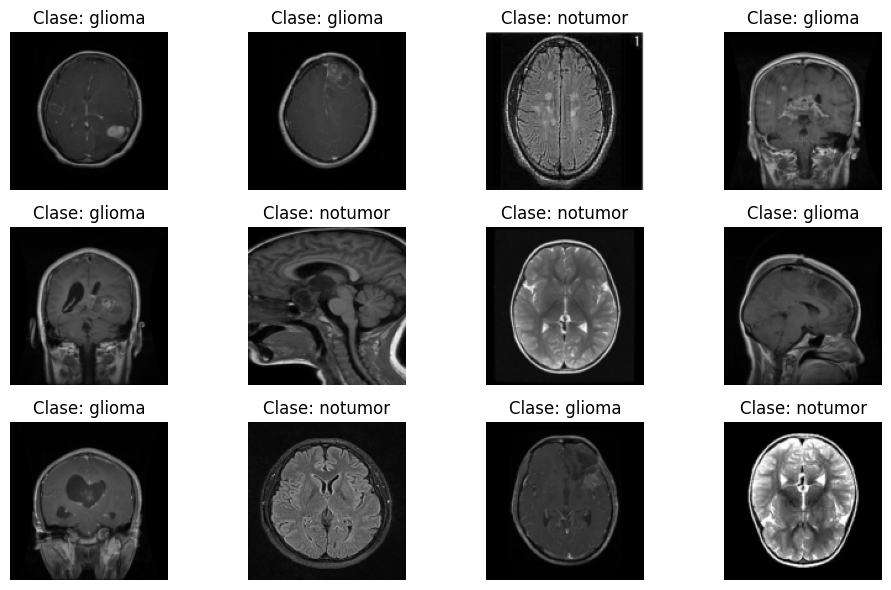

In [30]:
# Mapeo para saber qué número corresponde a qué clase
idx_to_class = {v: k for k, v in full_train_dataset.class_to_idx.items()}

def show_random_batch(dataset, n=12):
    plt.figure(figsize=(10, 6))

    # Seleccionar un cierto número de imágenes al azar de todo el dataset
    random_indices = random.sample(range(len(dataset)), n)

    for i, idx in enumerate(random_indices):
        x, y = dataset[idx]
        plt.subplot(3, 4, i+1)

        # Convertir formato de PyTorch a imagen normal (NumPy)
        img = x.permute(1, 2, 0).numpy()

        # Desnormalizar para quitar el fondo negro
        mean = np.array([0.5, 0.5, 0.5])
        std = np.array([0.5, 0.5, 0.5])
        img = std * img + mean

        # Asegurar que los valores de color estén en el rango correcto [0, 1]
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(f"Clase: {idx_to_class[int(y)]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Para ver las imágenes en la cuadrícula
show_random_batch(full_train_dataset, n=12)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [25]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 3, 128, 128]), torch.Size([128]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [31]:
import torch.nn as nn
import torch.nn.functional as F

# Usar las clases del dataset filtrado ('glioma' y 'notumor')
num_classes = len(full_train_dataset.classes)  # 2 clases

class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=2, dropout_p=0.3):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Reduce el mapa de características a 1x1 independientemente del tamaño de entrada
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, num_classes)  # Salida para 2 clases: glioma y notumor
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instanciar el modelo y enviarlo al dispositivo (GPU o CPU)
model_scratch = BrainTumorCNN(num_classes=num_classes, dropout_p=0.3).to(device)
model_scratch

BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [74]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Actualización de la función para que SÍ devuelva y_true y y_pred
def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss, correct = 0.0, 0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

            probs = F.softmax(outputs, dim=1)[:, 1]

            # Aquí se guardan los datos reales
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = running_loss / len(dataloader.dataset)
    val_acc = correct / len(dataloader.dataset)
    val_auc = roc_auc_score(all_labels, all_probs)
    return val_acc, val_auc, all_labels, all_preds, all_probs, val_loss

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [67]:
# Se usa el nombre de la red que definimos arriba (BrainTumorCNN)
model_aug = BrainTumorCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

#Se ajusta para que se trabajen 15 épocas
epochs = 15
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)

    val_acc, val_auc, _, _, _, _ = evaluate(model_aug, val_loader, criterion)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.2779 | val_acc=0.9643 | val_auc=0.9908
Epoch 01 | train_loss=0.2779 | val_acc=0.9643 | val_auc=0.9908
Epoch 02 | train_loss=0.1684 | val_acc=0.9054 | val_auc=0.9902
Epoch 02 | train_loss=0.1684 | val_acc=0.9054 | val_auc=0.9902
Epoch 03 | train_loss=0.1454 | val_acc=0.5107 | val_auc=0.9902
Epoch 03 | train_loss=0.1454 | val_acc=0.5107 | val_auc=0.9902
Epoch 04 | train_loss=0.1280 | val_acc=0.9821 | val_auc=0.9955
Epoch 04 | train_loss=0.1280 | val_acc=0.9821 | val_auc=0.9955
Epoch 05 | train_loss=0.1211 | val_acc=0.9696 | val_auc=0.9972
Epoch 05 | train_loss=0.1211 | val_acc=0.9696 | val_auc=0.9972
Epoch 06 | train_loss=0.0873 | val_acc=0.9750 | val_auc=0.9953
Epoch 06 | train_loss=0.0873 | val_acc=0.9750 | val_auc=0.9953
Epoch 07 | train_loss=0.0975 | val_acc=0.9839 | val_auc=0.9978
Epoch 07 | train_loss=0.0975 | val_acc=0.9839 | val_auc=0.9978
Epoch 08 | train_loss=0.1086 | val_acc=0.5107 | val_auc=0.9801
Epoch 08 | train_loss=0.1086 | val_acc=0.5107 | val_auc

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


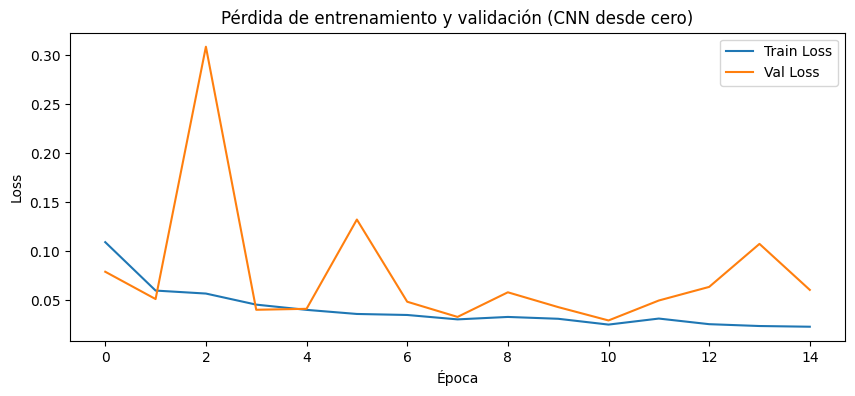

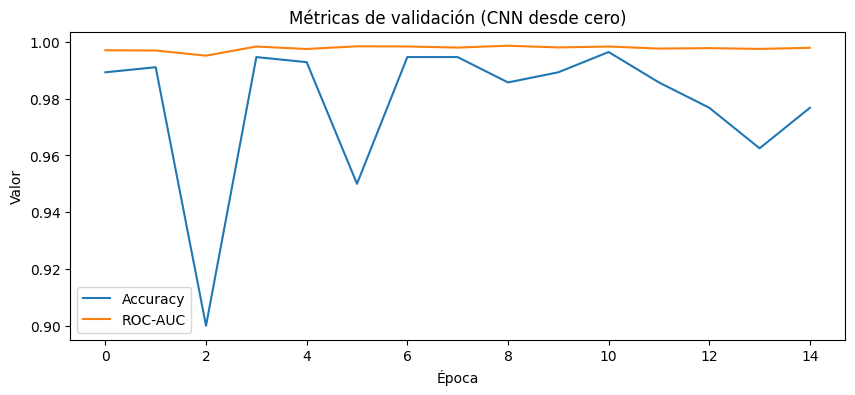

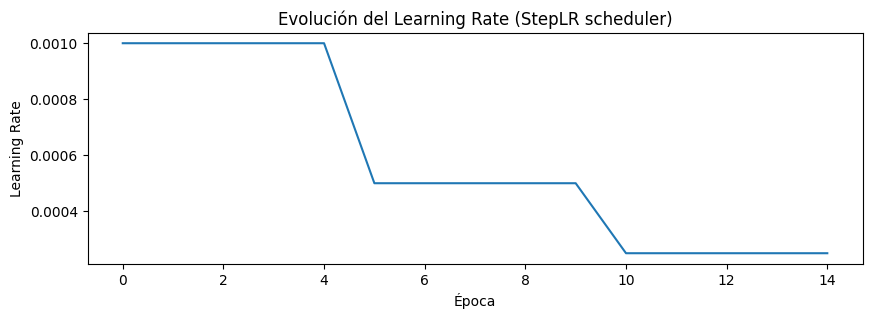

In [68]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train Loss")
plt.plot(history_scratch["val_loss"], label="Val Loss")
plt.title("Pérdida de entrenamiento y validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(history_scratch["lr"])
plt.title("Evolución del Learning Rate (StepLR scheduler)")
plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.show()

### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [69]:
test_acc, test_auc, y_true, y_pred, y_prob, _ = evaluate(model_scratch, test_loader, criterion)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}\n")

print(classification_report(y_true, y_pred, digits=4, target_names=full_train_dataset.classes))

cm = confusion_matrix(y_true, y_pred)
print("Matriz de Confusión:")
print(cm)

Test accuracy: 0.8950
Test ROC-AUC:  0.9291

              precision    recall  f1-score   support

      glioma     0.9540    0.8300    0.8877       400
     notumor     0.8496    0.9600    0.9014       400

    accuracy                         0.8950       800
   macro avg     0.9018    0.8950    0.8946       800
weighted avg     0.9018    0.8950    0.8946       800

Matriz de Confusión:
[[332  68]
 [ 16 384]]


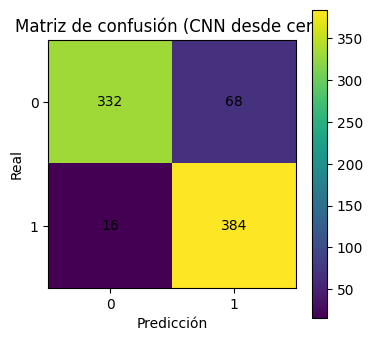

In [70]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [71]:
# Definición de las transformaciones de aumento
transform_aug = T.Compose([
    T.Resize((128, 128)), # Estandarizar el tamaño
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Cargar el dataset base y aplicar la función de filtrar a 2 clases
dataset_aug = ImageFolder(train_dir, transform=transform_aug)
dataset_aug = filter_2_classes(dataset_aug, ['glioma', 'notumor'])


In [73]:
# Dividir usando la MISMA semilla (42) para que los datos de entrenamiento y validación sean los mismos
val_size = int(len(dataset_aug) * 0.2)
train_size = len(dataset_aug) - val_size
train_dataset_aug, _ = random_split(dataset_aug, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Crear el nuevo DataLoader
batch_size = 32
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Crear una instancia del modelo con aumento de datos
model_aug = BrainTumorCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _, _ = evaluate(model_aug, val_loader, criterion) # Actualización de la evaluación

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.2896 | val_acc=0.7982 | val_auc=0.9875
Epoch 02 | train_loss=0.1752 | val_acc=0.9554 | val_auc=0.9907
Epoch 03 | train_loss=0.1303 | val_acc=0.9018 | val_auc=0.9845
Epoch 04 | train_loss=0.1530 | val_acc=0.5107 | val_auc=0.9828
Epoch 05 | train_loss=0.1227 | val_acc=0.9804 | val_auc=0.9959
Epoch 06 | train_loss=0.0978 | val_acc=0.9536 | val_auc=0.9961


### 6.1. Comparación rápida


In [76]:
# Retirando el 'criterion' y un '_' extra
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(model_aug, test_loader, criterion)

print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8950 | test_auc=0.9291
Con augmentation  | test_acc=0.8525 | test_auc=0.9235


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [78]:
import torchvision.models as models
from torch.utils.data import DataLoader, random_split

# Transformaciones para Transfer Learning (224x224 y normalización de ImageNet)
transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    # Eliminamos el Lambda porque ImageFolder ya lee en 3 canales
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cargar las carpetas locales y filtrar a 2 clases
dataset_tl = ImageFolder(train_dir, transform=transform_tl_train)
dataset_tl = filter_2_classes(dataset_tl, ['glioma', 'notumor'])

test_dataset_tl = ImageFolder(test_dir, transform=transform_tl_eval)
test_dataset_tl = filter_2_classes(test_dataset_tl, ['glioma', 'notumor'])

# Dividir train en train y val (80/20) con la misma semilla
val_size = int(len(dataset_tl) * 0.2)
train_size = len(dataset_tl) - val_size
train_dataset_tl, val_dataset_tl = random_split(dataset_tl, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Le quitamos el data augmentation al set de validación
val_dataset_tl.dataset.transform = transform_tl_eval

# DataLoaders (Bajé el batch_size a 32 para evitar que te quedes sin memoria de video al subir la resolución a 224)
batch_size_tl = 32
train_loader_tl = DataLoader(train_dataset_tl, batch_size=batch_size_tl, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=batch_size_tl, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=batch_size_tl, shuffle=False, num_workers=2, pin_memory=True)

# Comprobar la forma del batch
forma_batch = next(iter(train_loader_tl))[0].shape
print(f"Forma del batch: {forma_batch}")

Forma del batch: torch.Size([32, 3, 224, 224])


### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [79]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [81]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

print("Iniciando Transfer Learning (Stage 1)...")
for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)

    # Ajuste: Agregamos el criterion y un "_" extra para los 6 valores
    val_acc, val_auc, _, _, _, _ = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Iniciando Transfer Learning (Stage 1)...
Stage1 Epoch 01 | train_loss=0.1082 | val_acc=0.9929 | val_auc=0.9999
Stage1 Epoch 02 | train_loss=0.0706 | val_acc=0.9929 | val_auc=0.9999
Stage1 Epoch 03 | train_loss=0.0576 | val_acc=0.9946 | val_auc=0.9999
Stage1 Epoch 04 | train_loss=0.0521 | val_acc=0.9946 | val_auc=0.9999


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [82]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [86]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
criterion = nn.CrossEntropyLoss()
epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

print("Iniciando Transfer Learning (Stage 2: Fine-Tuning)...")
for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)

    # Ajuste reiterativo del criterion y el '_' extra
    val_acc, val_auc, _, _, _, _ = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Iniciando Transfer Learning (Stage 2: Fine-Tuning)...
Stage2 Epoch 01 | train_loss=0.0046 | val_acc=0.9964 | val_auc=1.0000
Stage2 Epoch 02 | train_loss=0.0078 | val_acc=0.9946 | val_auc=1.0000
Stage2 Epoch 03 | train_loss=0.0051 | val_acc=0.9982 | val_auc=1.0000
Stage2 Epoch 04 | train_loss=0.0018 | val_acc=0.9982 | val_auc=1.0000


### 7.3. Evaluación en test del modelo con transfer learning


In [88]:
# Evaluamos el modelo de Transfer Learning en el set de prueba
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl, _ = evaluate(resnet, test_loader_tl, criterion)

print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()

# Añadimos target_names para ver las etiquetas claras
print(classification_report(y_true_tl, y_pred_tl, digits=4, target_names=dataset_tl.classes))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.9100 | test_auc=0.9667

              precision    recall  f1-score   support

      glioma     1.0000    0.8200    0.9011       400
     notumor     0.8475    1.0000    0.9174       400

    accuracy                         0.9100       800
   macro avg     0.9237    0.9100    0.9093       800
weighted avg     0.9237    0.9100    0.9093       800



array([[328,  72],
       [  0, 400]])

### 7.4. Comparación global (resumen)


In [89]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8950 | auc=0.9291
CNN desde cero (con aug)  | acc=0.8525 | auc=0.9235
Transfer learning (ResNet) | acc=0.9100 | auc=0.9667


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [90]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


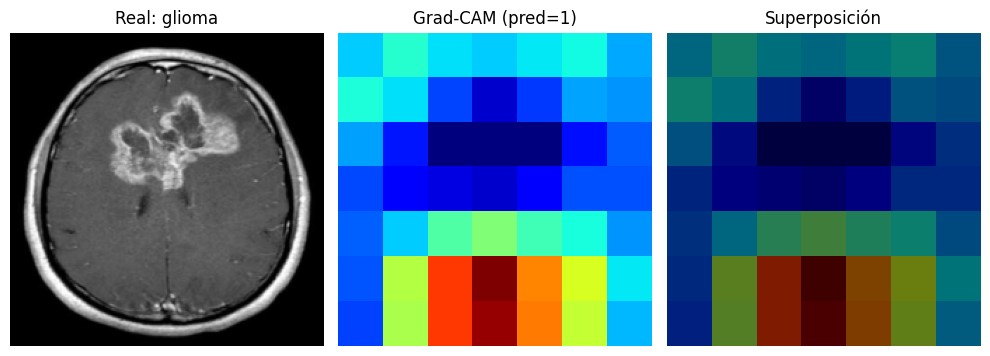

In [94]:
idx = 0
x, y = test_dataset_tl[idx]

# Pasamos 'x' directamente
# Enviar datos al mismo dispositivo (GPU/CPU) que el modelo.
cam, pred_class = grad_cam(resnet, x.to(device))

# Desnormalizar la imagen original para visualizarla a color
# .cpu() por si el tensor estaba en la tarjeta gráfica
img = x.cpu().permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

# Obtenemos el nombre real de la etiqueta
nombre_clase = test_dataset_tl.classes[int(y)]

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Real: {nombre_clase}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap='jet')
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

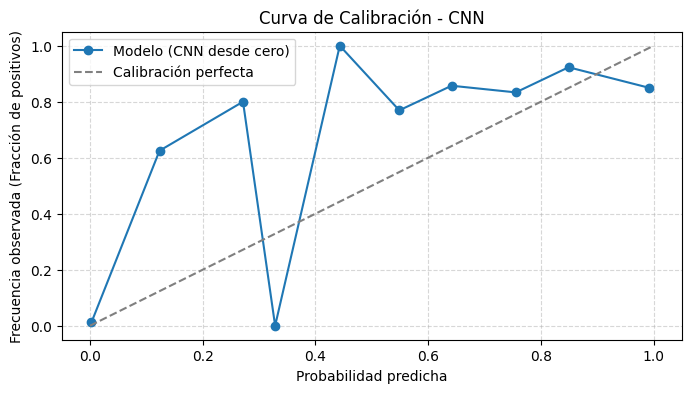

In [96]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

plt.figure(figsize=(8, 4))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo (CNN desde cero)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada (Fracción de positivos)")
plt.title("Curva de Calibración - CNN")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [97]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.
